In [100]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly_express as px 
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from utils.wrangle import wrangle_data
from utils.make_pred import make_prediction


# Project Workflow
### In this project I will follow the following Data Science and machine learning Workflow
***1- Prepare Data***    
    - Import  
    - Explore  
    - Split  

***2- Build Model***    
    - Baseline  
    - Iterate  
    - Evaluation  

***3- Communicating Results***   

In [2]:
# Import data raw file
# Reading the first raw data file
df1 = pd.read_csv("../data/raw/mexico-city-real-estate-1.csv")
df1.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [3]:
# lat-lon column
# Creating a seperate lat and loan columns from the column "lat-lon"
df1[["lat", "lon"]]=df1["lat-lon"].str.split(",", expand=True)

In [4]:
# drop the old "lat-lon column"
df1.drop(columns="lat-lon", inplace=True)

In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   place_with_parent_names     4628 non-null   str    
 3   price                       4538 non-null   float64
 4   currency                    4538 non-null   str    
 5   price_aprox_local_currency  4538 non-null   float64
 6   price_aprox_usd             4538 non-null   float64
 7   surface_total_in_m2         1668 non-null   float64
 8   surface_covered_in_m2       4436 non-null   float64
 9   price_usd_per_m2            1150 non-null   float64
 10  price_per_m2                4249 non-null   float64
 11  floor                       291 non-null    float64
 12  rooms                       136 non-null    float64
 13  expenses                    5 non-null      

In [6]:
# cast the lat and lon coluymns to float
df1[["lat", "lon"]]= df1[["lat","lon"]].astype("float")

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   place_with_parent_names     4628 non-null   str    
 3   price                       4538 non-null   float64
 4   currency                    4538 non-null   str    
 5   price_aprox_local_currency  4538 non-null   float64
 6   price_aprox_usd             4538 non-null   float64
 7   surface_total_in_m2         1668 non-null   float64
 8   surface_covered_in_m2       4436 non-null   float64
 9   price_usd_per_m2            1150 non-null   float64
 10  price_per_m2                4249 non-null   float64
 11  floor                       291 non-null    float64
 12  rooms                       136 non-null    float64
 13  expenses                    5 non-null      

In [8]:
df1.head()

,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788
1,sell,house,|Iztapalapa|Distrito Federal|México|,1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557
2,sell,apartment,|Tlalpan|Distrito Federal|México|,926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838


In [9]:
# Extract the state column from "place with parents name column"
df1["state"]=df1["place_with_parent_names"].str.split("|", expand=True)[2]

In [10]:
# Drop the "place_with_parent_name" column
df1.drop(["place_with_parent_names"], axis=1, inplace=True)

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   price                       4538 non-null   float64
 3   currency                    4538 non-null   str    
 4   price_aprox_local_currency  4538 non-null   float64
 5   price_aprox_usd             4538 non-null   float64
 6   surface_total_in_m2         1668 non-null   float64
 7   surface_covered_in_m2       4436 non-null   float64
 8   price_usd_per_m2            1150 non-null   float64
 9   price_per_m2                4249 non-null   float64
 10  floor                       291 non-null    float64
 11  rooms                       136 non-null    float64
 12  expenses                    5 non-null      float64
 13  properati_url               4628 non-null   

In [12]:
df1.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,state
0,sell,apartment,5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788,Distrito Federal
1,sell,house,1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557,Distrito Federal
2,sell,apartment,926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597,Distrito Federal
3,sell,apartment,6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788,Distrito Federal
4,sell,apartment,875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838,Quintana Roo


### Extracting new columns"price_usd" as in our dataset there is several columns decribing the price
### as the rate of USD to mexican pseo is 1 to 17 we can devide the price in peso "price" by 17 and get the price in USD

In [13]:
df1["price_usd"] = df1["price"].apply(lambda x: x/17).astype("float")

In [14]:
df1.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,state,price_usd
0,sell,apartment,5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788,Distrito Federal,323529.411765
1,sell,house,1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557,Distrito Federal,88941.176471
2,sell,apartment,926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597,Distrito Federal,54509.823529
3,sell,apartment,6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788,Distrito Federal,377058.823529
4,sell,apartment,875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838,Quintana Roo,51470.588235


In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   price                       4538 non-null   float64
 3   currency                    4538 non-null   str    
 4   price_aprox_local_currency  4538 non-null   float64
 5   price_aprox_usd             4538 non-null   float64
 6   surface_total_in_m2         1668 non-null   float64
 7   surface_covered_in_m2       4436 non-null   float64
 8   price_usd_per_m2            1150 non-null   float64
 9   price_per_m2                4249 non-null   float64
 10  floor                       291 non-null    float64
 11  rooms                       136 non-null    float64
 12  expenses                    5 non-null      float64
 13  properati_url               4628 non-null   

In [16]:
# According to the info the column "surface covered in m2" represents the area 
# let's rename it to be "area_m2"
df1.rename(columns={"surface_covered_in_m2": "area_m2"}, inplace=True)

In [17]:
df1.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,area_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,state,price_usd
0,sell,apartment,5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788,Distrito Federal,323529.411765
1,sell,house,1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557,Distrito Federal,88941.176471
2,sell,apartment,926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597,Distrito Federal,54509.823529
3,sell,apartment,6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788,Distrito Federal,377058.823529
4,sell,apartment,875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838,Quintana Roo,51470.588235


In [18]:
# drop the columns that have large numbers of nulls
df1.drop(["rooms","floor","expenses"], axis=1, inplace=True)

In [19]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   price                       4538 non-null   float64
 3   currency                    4538 non-null   str    
 4   price_aprox_local_currency  4538 non-null   float64
 5   price_aprox_usd             4538 non-null   float64
 6   surface_total_in_m2         1668 non-null   float64
 7   area_m2                     4436 non-null   float64
 8   price_usd_per_m2            1150 non-null   float64
 9   price_per_m2                4249 non-null   float64
 10  properati_url               4628 non-null   str    
 11  lat                         4144 non-null   float64
 12  lon                         4144 non-null   float64
 13  state                       4628 non-null   

# Leakage
Now let's frop all the leaky columns that can harm out model performance.
leaky columns such as "surface_total_in_m2 ", "price_usd_per_m2"  as we have already ["area_m2", "price_usd"]
columns and such leakage could affect our model performance

In [20]:
# drop leaky columns
df1.drop(columns=["price_usd_per_m2", "surface_total_in_m2"], inplace=True)

In [21]:
df1.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,area_m2,price_per_m2,properati_url,lat,lon,state,price_usd
0,sell,apartment,5500000.0,MXN,5450245.50,289775.66,54.0,101851.851852,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788,Distrito Federal,323529.411765
1,sell,house,1512000.0,MXN,1498321.97,79661.96,80.0,18900.000000,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557,Distrito Federal,88941.176471
2,sell,apartment,926667.0,MXN,918284.00,48822.82,100.0,9266.670000,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597,Distrito Federal,54509.823529
3,sell,apartment,6410000.0,MXN,6352013.39,337720.36,135.0,47481.481481,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788,Distrito Federal,377058.823529
4,sell,apartment,875000.0,USD,16457437.50,875000.00,263.0,3326.996198,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838,Quintana Roo,51470.588235


# Multicollinearity
This happen when we have two or more features that have strong corelation to each other which is not good for our model.
We can discover it using corelation matrix

In [22]:
df1.select_dtypes("float").corr()

,price,price_aprox_local_currency,price_aprox_usd,area_m2,price_per_m2,lat,lon,price_usd
price,1.000000,0.400029,0.400029,0.297881,0.144987,-0.065972,-0.117532,1.000000
price_aprox_local_currency,0.400029,1.000000,1.000000,0.181434,0.018678,0.071072,0.091361,0.400029
price_aprox_usd,0.400029,1.000000,1.000000,0.181434,0.018678,0.071072,0.091361,0.400029
area_m2,0.297881,0.181434,0.181434,1.000000,-0.011610,-0.002308,0.002318,0.297881
price_per_m2,0.144987,0.018678,0.018678,-0.011610,1.000000,-0.004961,-0.029717,0.144987
lat,-0.065972,0.071072,0.071072,-0.002308,-0.004961,1.000000,0.579534,-0.065972
lon,-0.117532,0.091361,0.091361,0.002318,-0.029717,0.579534,1.000000,-0.117532
price_usd,1.000000,0.400029,0.400029,0.297881,0.144987,-0.065972,-0.117532,1.000000


<Axes: >

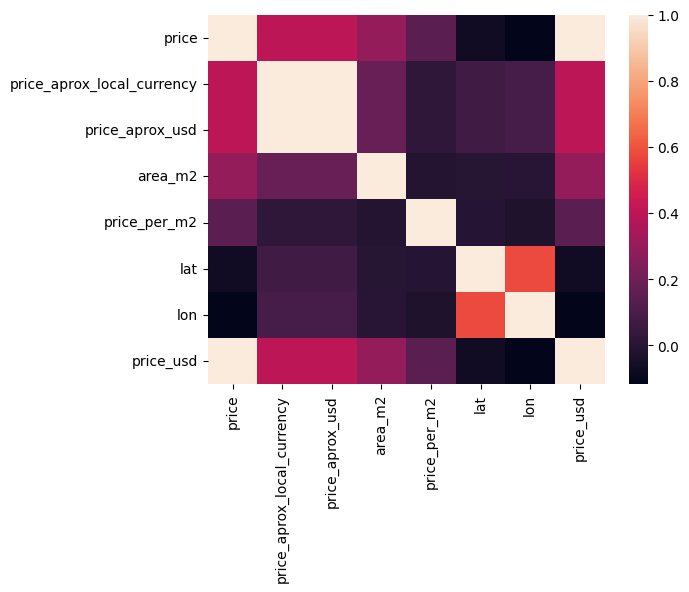

In [23]:
# Plotting a heat map to take a better look
sns.heatmap(df1.select_dtypes("float").corr())

In [24]:
# It's clear the the features related to the price have a multicollinearity
# Drop the high colrelated to each other columns
df1.drop(columns=["price_aprox_local_currency","price_aprox_usd", "price_per_m2","price"], inplace=True)

In [25]:
df1.head()

,operation,property_type,currency,area_m2,properati_url,lat,lon,state,price_usd
0,sell,apartment,MXN,54.0,http://miguel-hidalgo-df.properati.com.mx/o3zb...,23.634501,-102.552788,Distrito Federal,323529.411765
1,sell,house,MXN,80.0,http://iztapalapa.properati.com.mx/q7t0_venta_...,19.310330,-99.068557,Distrito Federal,88941.176471
2,sell,apartment,MXN,100.0,http://tlalpan.properati.com.mx/qbi4_venta_dep...,19.279771,-99.234597,Distrito Federal,54509.823529
3,sell,apartment,MXN,135.0,http://miguel-hidalgo-df.properati.com.mx/opeq...,23.634501,-102.552788,Distrito Federal,377058.823529
4,sell,apartment,USD,263.0,http://cancun.properati.com.mx/hg4t_venta_depa...,21.190264,-86.819838,Quintana Roo,51470.588235


# Low and High Cardinality 
Low and high cardinality features acutally are useless to our model, high cardilality column such as property_url will never help our linear regression model to make good prediction as every observation has it's own value.
Likewise if we will take a look at the low cardilaty column operation and currency.

In [26]:
df1.select_dtypes("str").nunique()

operation           1
property_type       4
currency            2
properati_url    4628
state               6
dtype: int64

In [27]:
df1.drop(columns=["currency","properati_url","operation"], inplace=True)

In [28]:
df1.head()

,property_type,area_m2,lat,lon,state,price_usd
0,apartment,54.0,23.634501,-102.552788,Distrito Federal,323529.411765
1,house,80.0,19.310330,-99.068557,Distrito Federal,88941.176471
2,apartment,100.0,19.279771,-99.234597,Distrito Federal,54509.823529
3,apartment,135.0,23.634501,-102.552788,Distrito Federal,377058.823529
4,apartment,263.0,21.190264,-86.819838,Quintana Roo,51470.588235


In [29]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  4628 non-null   str    
 1   area_m2        4436 non-null   float64
 2   lat            4144 non-null   float64
 3   lon            4144 non-null   float64
 4   state          4628 non-null   str    
 5   price_usd      4538 non-null   float64
dtypes: float64(4), str(2)
memory usage: 217.1 KB


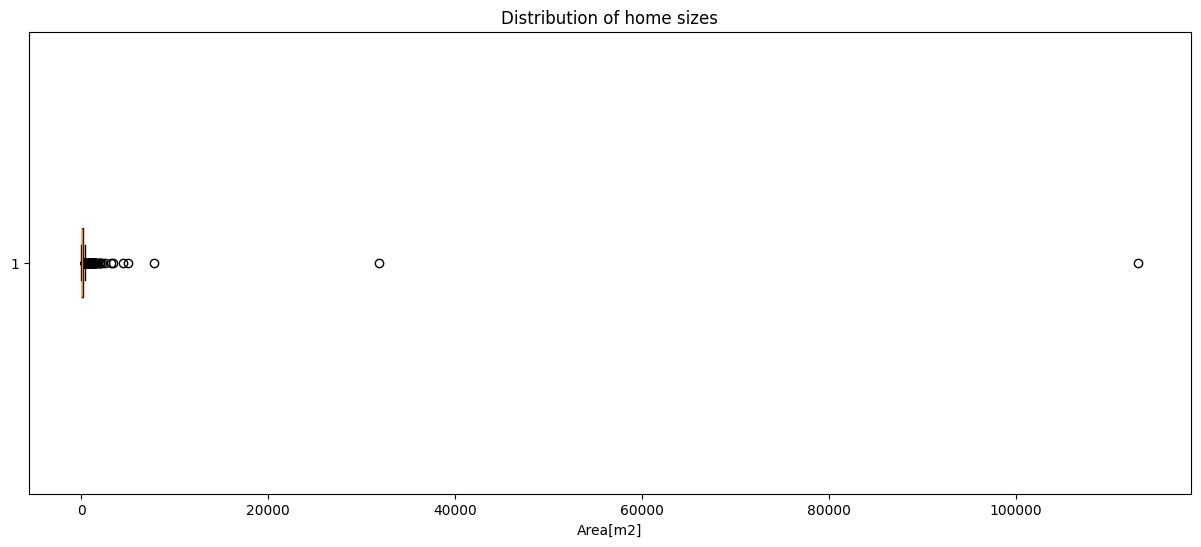

In [30]:
# Dealing with the Outliers
fig,ax = plt.subplots(figsize=(15,6))
ax.boxplot(df1["area_m2"].fillna(df1["area_m2"].mean()),vert=False);\
ax.set_xlabel("Area[m2]")
ax.set_title("Distribution of home sizes")
# Save the figure
plt.savefig("../reports/figures/box_plot.png", dpi=400)





In [31]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  4628 non-null   str    
 1   area_m2        4436 non-null   float64
 2   lat            4144 non-null   float64
 3   lon            4144 non-null   float64
 4   state          4628 non-null   str    
 5   price_usd      4538 non-null   float64
dtypes: float64(4), str(2)
memory usage: 217.1 KB


In [32]:
df1.head()

,property_type,area_m2,lat,lon,state,price_usd
0,apartment,54.0,23.634501,-102.552788,Distrito Federal,323529.411765
1,house,80.0,19.310330,-99.068557,Distrito Federal,88941.176471
2,apartment,100.0,19.279771,-99.234597,Distrito Federal,54509.823529
3,apartment,135.0,23.634501,-102.552788,Distrito Federal,377058.823529
4,apartment,263.0,21.190264,-86.819838,Quintana Roo,51470.588235


# EDA

***Exploratory Data Analysis***

In [33]:
# Distribtion of the price for the apartments
df1=df1[df1["property_type"]=="apartment"]
df1.head()

,property_type,area_m2,lat,lon,state,price_usd
0,apartment,54.0,23.634501,-102.552788,Distrito Federal,323529.411765
2,apartment,100.0,19.279771,-99.234597,Distrito Federal,54509.823529
3,apartment,135.0,23.634501,-102.552788,Distrito Federal,377058.823529
4,apartment,263.0,21.190264,-86.819838,Quintana Roo,51470.588235
5,apartment,87.0,19.432657,-99.177444,Distrito Federal,259764.705882


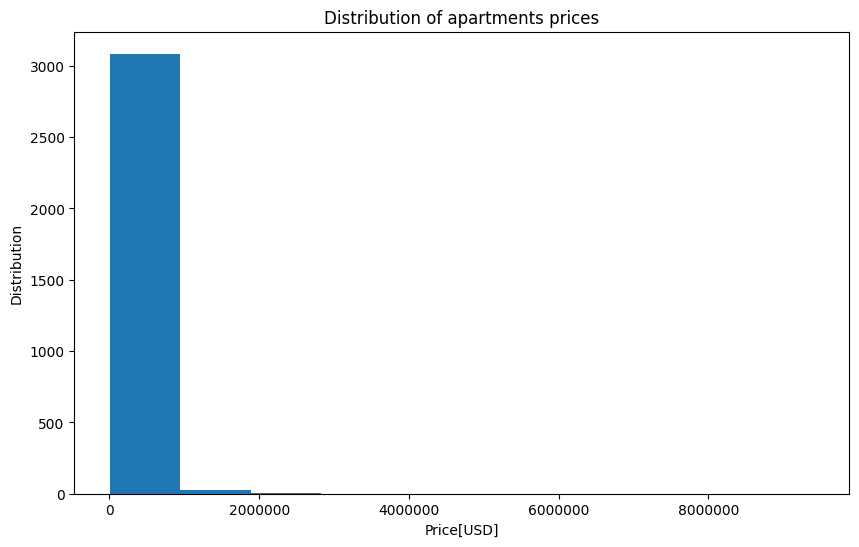

In [34]:
# Distribtion of the price for the apartments
fig,ax = plt.subplots(figsize=(10,6))
ax.hist(df1["price_usd"]);
plt.ticklabel_format(style='plain', axis='x')
ax.set_xlabel("Price[USD]")
ax.set_ylabel("Distribution")
ax.set_title("Distribution of apartments prices")
plt.savefig("../reports/figures/apartments_prices.png", dpi=150)



We can see that most of the apartments price between 100_000,400_000 USD, and we still have ofcourse outliers which maybe depends on the location of the apartment.

In [35]:
# Lets figure out if the state has a relationship to the price's mean
state_grouped = df1.groupby("state")["price_usd"].mean().sort_values()
state_grouped

state
Othón P. Blanco      11529.411765
Zacatecas            31470.588235
Solidaridad          38465.158371
Quintana Roo         75651.332147
Benito Juárez       151401.960784
Distrito Federal    165051.689073
Name: price_usd, dtype: float64

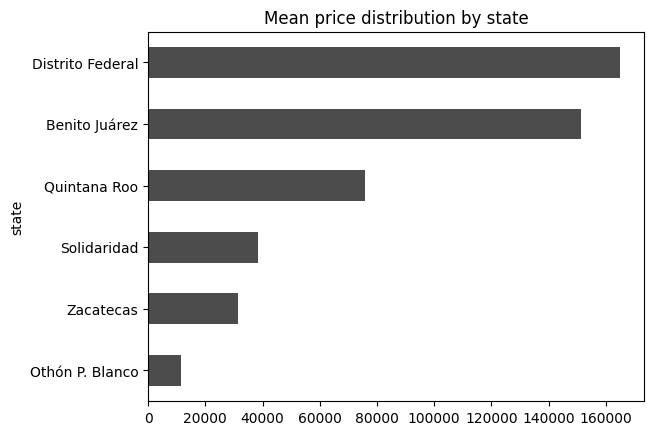

In [36]:
# However it's clearly that the capital has the more high prices, let's plot it
state_grouped.plot(kind="barh", color="black", alpha=0.7);
plt.title("Mean price distribution by state")
plt.savefig("../reports/figures/price_by_state.png", dpi=150)

In [37]:
# Visualizing the prices distribution
fig = px.scatter_mapbox(
    df1,
    lat="lat",
    lon="lon",
    center={"lat": 19.4326, "lon": -99.1332}, # map will center in mexico
    width=600,
    height=600,
    color="price_usd",
    hover_data=["price_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

C:\Users\m\AppData\Local\Temp\ipykernel_12576\4144097745.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [38]:
# make another mask for the price to get the prices < 400_000 usd
df1 = df1[df1["price_usd"]<400_000]


In [39]:
df1.head()

,property_type,area_m2,lat,lon,state,price_usd
0,apartment,54.0,23.634501,-102.552788,Distrito Federal,323529.411765
2,apartment,100.0,19.279771,-99.234597,Distrito Federal,54509.823529
3,apartment,135.0,23.634501,-102.552788,Distrito Federal,377058.823529
4,apartment,263.0,21.190264,-86.819838,Quintana Roo,51470.588235
5,apartment,87.0,19.432657,-99.177444,Distrito Federal,259764.705882


In [40]:
# Focusing on the apartmens that located in the capital Distrito Federal
df1 = df1[df1["state"]=="Distrito Federal"]
df1.head()

,property_type,area_m2,lat,lon,state,price_usd
0,apartment,54.0,23.634501,-102.552788,Distrito Federal,323529.411765
2,apartment,100.0,19.279771,-99.234597,Distrito Federal,54509.823529
3,apartment,135.0,23.634501,-102.552788,Distrito Federal,377058.823529
5,apartment,87.0,19.432657,-99.177444,Distrito Federal,259764.705882
6,apartment,100.0,19.367025,-99.170349,Distrito Federal,185294.117647


In [41]:
# Checking the corelation between the price and the area
corr = df1["price_usd"].corr(df1["area_m2"])
corr

np.float64(0.004749135586421783)

In [42]:
# Dealing with outliers of the area 
low, high = df1["area_m2"].quantile([0.1,0.9])
low,high

# Mask for the area 
df1 = df1[df1["area_m2"].between(low,high)]

In [43]:
df1 = df1.reset_index(drop=True)

The corelation cooffcient is 0.26 which is not a strong indicator that the price is highly affected by the area, on the other hand the location is more corelated to the price.

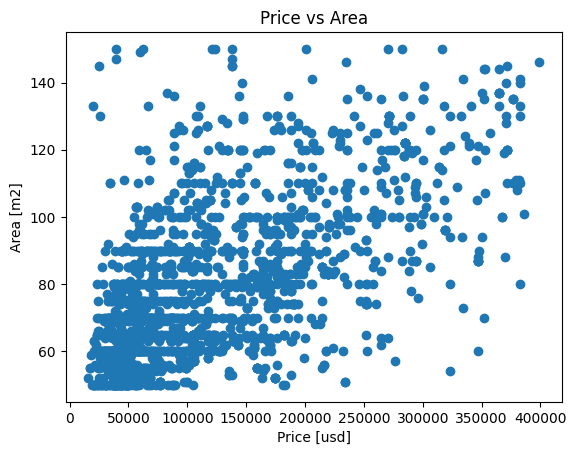

In [44]:
# Visualizing the corelation between the price and the area
plt.scatter(df1["price_usd"], df1["area_m2"])
plt.xlabel("Price [usd]")
plt.ylabel("Area [m2]")
plt.title("Price vs Area")
plt.savefig("../reports/figures/Price_vs_area.png", dpi=150)

So far we've made several steps to clean and mask our dataset and also some EDA using our visualization tools and our pandas tools, But it's a best practice to include all this work inside one class or fuction and use it as we will repeat all this steps with the other datasets.

In [45]:
from glob import glob
files = glob("../data/raw/mexico-city-real-estate-*.csv")
files

['../data/raw\\mexico-city-real-estate-1.csv',
 '../data/raw\\mexico-city-real-estate-2.csv',
 '../data/raw\\mexico-city-real-estate-3.csv']

In [46]:
frames = [wrangle_data(file) for file in files]

In [47]:
frames[0].head()

,area_m2,lat,lon,price_usd
0,54.0,23.634501,-102.552788,323529.411765
1,100.0,19.279771,-99.234597,54509.823529
2,135.0,23.634501,-102.552788,377058.823529
3,87.0,19.432657,-99.177444,259764.705882
4,100.0,19.367025,-99.170349,185294.117647


In [48]:
df = pd.concat(frames, axis=0, ignore_index=True)

In [49]:
df.head()

,area_m2,lat,lon,price_usd
0,54.0,23.634501,-102.552788,323529.411765
1,100.0,19.279771,-99.234597,54509.823529
2,135.0,23.634501,-102.552788,377058.823529
3,87.0,19.432657,-99.177444,259764.705882
4,100.0,19.367025,-99.170349,185294.117647


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area_m2    5848 non-null   float64
 1   lat        5445 non-null   float64
 2   lon        5445 non-null   float64
 3   price_usd  5848 non-null   float64
dtypes: float64(4)
memory usage: 182.9 KB


In [51]:
# Test driven
assert df.shape[0] == 5848, f"df should have no more than 5848 observations not {df.shape[0]}"

In [52]:
df.to_csv("../data/processed/final_data.csv")

# split the data

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
df.head()

,area_m2,lat,lon,price_usd
0,54.0,23.634501,-102.552788,323529.411765
1,100.0,19.279771,-99.234597,54509.823529
2,135.0,23.634501,-102.552788,377058.823529
3,87.0,19.432657,-99.177444,259764.705882
4,100.0,19.367025,-99.170349,185294.117647


In [55]:
# vertical split
X = df.drop(["price_usd"], axis=1)
y=df["price_usd"]


In [68]:
# Horizontal split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, shuffle=True)

In [69]:
X_train.shape, y_train.shape

((5263, 3), (5263,))

In [70]:
X_test.shape, y_test.shape

((585, 3), (585,))

In [71]:
# import the linear regression model and the imputer
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_absolute_error

In [72]:
# dump model - baseline
y_pred_baseline= [y_train.mean() for i in y_train]
mae_baseline = round(mean_absolute_error(y_pred_baseline, y_train),2)
mae_baseline

67792.26

Here we gor the mae_baseline 67440.78 and we need to beat this number when cauculating the mean absolute error for the training set


In [73]:
model = make_pipeline(
    
    SimpleImputer(),
    LinearRegression()
)

In [74]:
# fit the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [75]:
# checking the model performance on the traing set to check if it overfits the data
y_pred_train = model.predict(X_train)

In [76]:
y_pred_train

array([127831.22620658,  97316.1802074 , 250264.49564891, ...,
        86369.62994977, 109789.32781639,  62028.90074611], shape=(5263,))

In [77]:
# Evaluating the model performance on the training set
train_MAE = round(mean_absolute_error(y_train, y_pred_train),2)
train_MAE

52683.41

In [78]:
y_pred_test = model.predict(X_test)
tese_MAE = round(mean_absolute_error(y_test, y_pred_test),2)
tese_MAE

53455.04

# Communicating results

In [ ]:
# Extract the feature importances and the intercept
intercept = model.named_steps["linearregression"].intercept_
intercept

np.float64(-1900208.3449909014)

In [ ]:
coefficients = model.named_steps["linearregression"].coef_

array([  2189.31005153,  -3524.36800697, -19281.2549162 ])

In [82]:
feature_names = X_train.columns
feature_names

Index(['area_m2', 'lat', 'lon'], dtype='str')

In [ ]:
# Feature importances series
fea_imp = pd.Series(coefficients, index = feature_names)
fea_imp

area_m2     2189.310052
lat        -3524.368007
lon       -19281.254916
dtype: float64

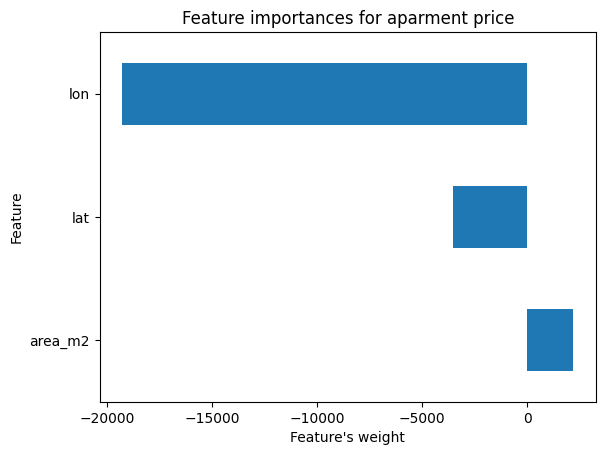

In [94]:
fea_imp.sort_values(key=abs).plot(kind="barh")
plt.xlabel("Feature's weight")
plt.ylabel("Feature")
plt.title("Feature importances for aparment price")
plt.savefig("../reports/figures/Featture_importances.png", dpi=150)

In [109]:
# Linear model
equ = f"Price = {intercept.round(2)} + {coefficients[0].round(2)} * area + {coefficients[1].round(2)} * lat + {coefficients[2].round(2)} * lon"
equ

'Price = -1900208.34 + 2189.31 * area + -3524.37 * lat + -19281.25 * lon'

In [ ]:
# Linear model equation
model 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [96]:
# Saving the model
import joblib
joblib.dump(model,"../models/model.pkl")

['../models/model.pkl']

# Prediction Function
one of the most important steps is to deploy the model and make it usable for the world even with a simple prediction function


In [104]:
make_prediction(84, 19.3, -99.1)


'Predicted apartmen price is: [126445.76]'

In [105]:
make_prediction(lat=19.3, area=84, lon=-99)

'Predicted apartmen price is: [124517.63]'